# Create Identity Scaling figure
- create figure showing the infidelity scaling with second qubit detuning of the identity gate for rabi and ccd schemes
- should be general - ie interms of rabi frequency
- should be pretty - with descriptive title etc

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# lets me import from a different directory
import sys 
sys.path.append("/Users/archie/documents/year4/project/code")

import spin_tools.hamiltonians as hamiltonians
from spin_tools.gates import *
import spin_tools.quantum_tools as qt
from spin_tools.floquet_tools import ccd_floquet

In [29]:
turquoise, hot_pink = "#00CED1", "#FF31CE"


In [30]:
steel_blue, plum = "#4682B4", "#B44682"

# CCD

In [47]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005


# CCD parameters
phi_0, epsilon_m, phase_freq, theta_m = 0, rabi_freq/4, rabi_freq, 0


# Integration parameters
tol = 10**-12
evaluation_points = 2000
evaluation_time = 4/rabi_freq

# iteration parameters
detunings = np.linspace(0, 40*rabi_freq, 1000)

fids_1 = []
fids_2 = []
fids_combined = []

# First calculate fidelity for qubit 1 (root-x gate)
times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa,
                            driving_freq=driving_freq,
                            natural_freq=natural_freq, 
                            rabi_freq=rabi_freq, 
                            phi_0=phi_0,
                            epsilon_m=epsilon_m,
                            phase_freq=phase_freq,
                            theta_m=theta_m,
                            atol=tol,
                            rtol=tol)
fid_1 = qt.calculate_fidelities(identity, Us_driving_frame, 2)

# For each detuning, calculate fidelity for qubit 2 (identity gate)
for detuning in detunings:
    fids_1.append(fid_1)
    # calculate the effective the ccd time evolution unitaries
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa,
                            driving_freq=driving_freq,
                            natural_freq=natural_freq-detuning, 
                            rabi_freq=rabi_freq, 
                            phi_0=phi_0,
                            epsilon_m=epsilon_m,
                            phase_freq=phase_freq,
                            theta_m=theta_m)
    

    ccd_floquet_freq = np.sign(detuning)*2*ccd_floquet(natural_freq-detuning, driving_freq, rabi_freq, phi_0, epsilon_m, phase_freq, theta_m)[4]

    transformed_Us = qt.phase_boost_unitaries(Us_driving_frame, ccd_floquet_freq, times)

    # Calculate fidelity for qubit 2 (identity gate)
    fid_2 = qt.calculate_fidelities(np.eye(2), transformed_Us, 2)
    fids_2.append(fid_2)
    
    # Calculate combined fidelity
    fid_combined = (np.abs((6*fid_1-2)*(6*fid_2-2))+4)/20
    fids_combined.append(fid_combined)

# Extract the final time step fidelity for each detuning
final_fids_combined_ccd = [fid[-1] for fid in fids_combined]

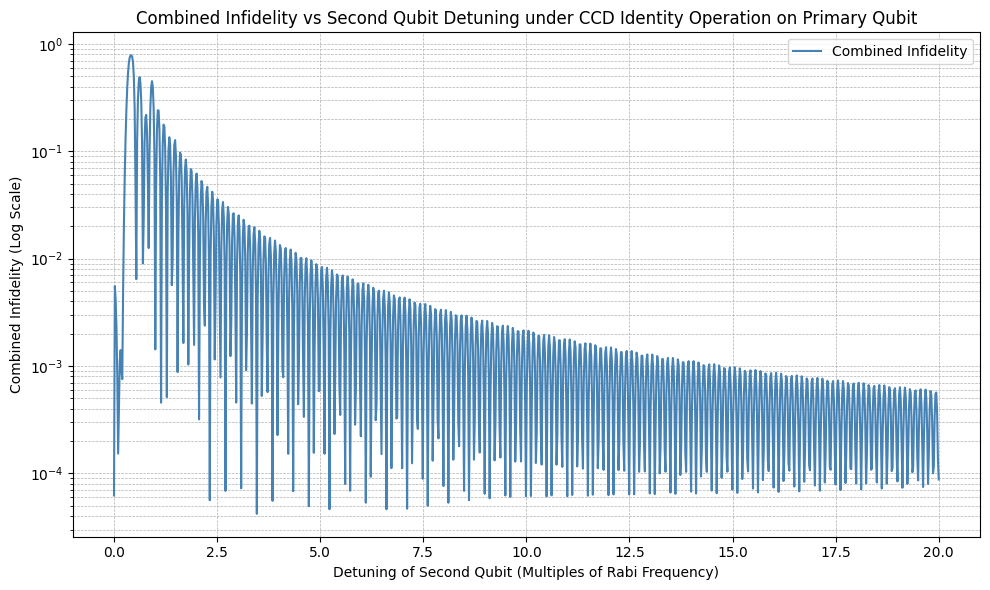

In [52]:

# find combdined infidelity
infidelities_combined = 1-np.array(final_fids_combined)

# Normalize detunings by Rabi frequency
detunings_normalized = detunings / rabi_freq

# Plot combined infidelity vs normalized detuning on a logarithmic scale
plt.figure(figsize=(10, 6))
plt.semilogy(detunings_normalized, infidelities_combined, label="Combined Infidelity", color=steel_blue)
plt.xlabel("Detuning of Second Qubit (Multiples of Rabi Frequency)")
plt.ylabel("Combined Infidelity (Log Scale)")
plt.title("Combined Infidelity vs Second Qubit Detuning under CCD Identity Operation on Primary Qubit")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


# Rabi

In [ ]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005




# Integration parameters
tol = 10**-5
evaluation_points = 2000
evaluation_time = 4/rabi_freq

# iteration parameters
detunings = np.linspace(0, 20*rabi_freq, 1000)


fids_1 = []
fids_2 = []
fids_combined = []

times, Us_driving_frame = qt.calculate_unitaries(
        1, 
        evaluation_time, 
        evaluation_points, 
        hamiltonians.rabi_rwa, 
        natural_freq=natural_freq, 
        driving_freq=driving_freq, 
        rabi_freq=rabi_freq, 
        atol=tol, 
        rtol=tol
    )
fid_1 = qt.calculate_fidelities(identity, Us_driving_frame, 2)


for detuning in detunings:
    times, Us_driving_frame = qt.calculate_unitaries(
        1, 
        evaluation_time, 
        evaluation_points, 
        hamiltonians.rabi_rwa, 
        natural_freq=natural_freq-detuning, 
        driving_freq=driving_freq, 
        rabi_freq=rabi_freq, 
        atol=tol, 
        rtol=tol
    )
    fids_1.append(fid_1)

    effective_rabi_freq = np.sign(detuning)*np.sqrt(rabi_freq**2 + detuning**2)
    Us_effective_rabi = qt.phase_boost_unitaries(Us_driving_frame, effective_rabi_freq, times)
    fid_2 = qt.calculate_fidelities(np.eye(2), Us_effective_rabi, 2)
    fids_2.append(fid_2)

    fid_combined = (np.abs((6*fid_1-2)*(6*fid_2-2))+4)/20
    fids_combined.append(fid_combined)

# Extract the final time step fidelity for each detuning
final_fids_combined_rabi = [fid[-1] for fid in fids_combined]

detunings_normalized = detunings / rabi_freq

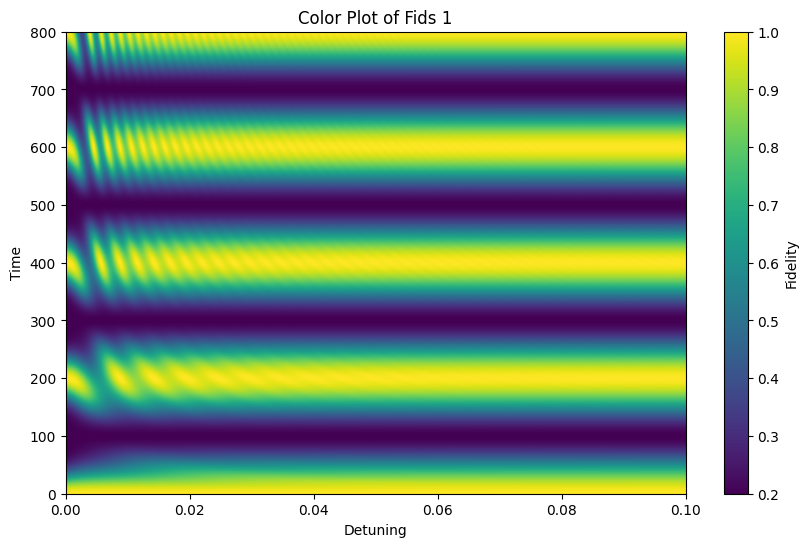

In [55]:
plt.figure(figsize=(10, 6))
plt.imshow(np.array(fids_combined).T, aspect='auto', extent=[detunings[0], detunings[-1], 0, evaluation_time], origin='lower', cmap='viridis')
plt.colorbar(label='Fidelity')
plt.xlabel('Detuning')
plt.ylabel('Time')
plt.title('Color Plot of Fids 1')
plt.show()

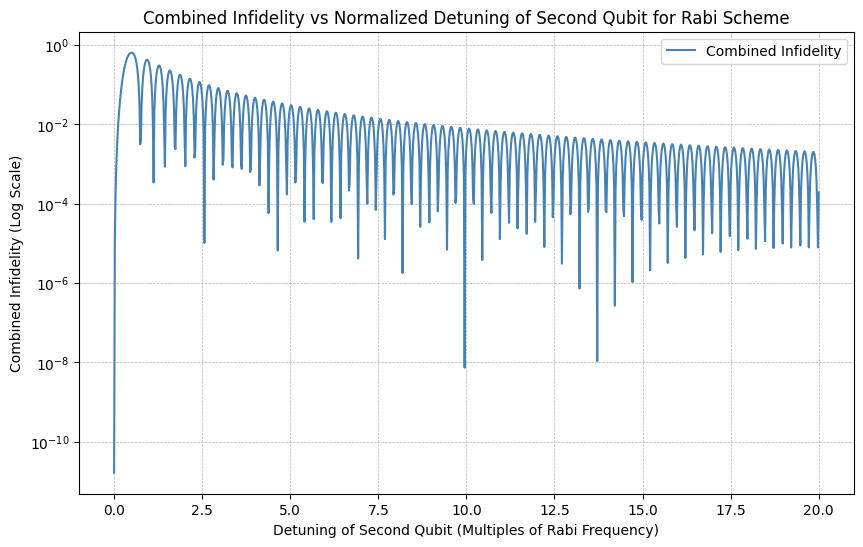

In [56]:
# find combdined infidelity
infidelities_combined_rabi = 1-np.array(final_fids_combined_rabi)

# Normalize detunings by Rabi frequency
detunings_normalized = detunings / rabi_freq

# Plot combined infidelity vs normalized detuning on a logarithmic scale
plt.figure(figsize=(10, 6))
plt.semilogy(detunings_normalized, infidelities_combined_rabi, label="Combined Infidelity", color=steel_blue)
plt.xlabel("Detuning of Second Qubit (Multiples of Rabi Frequency)")
plt.ylabel("Combined Infidelity (Log Scale)")
plt.title("Combined Infidelity vs Normalized Detuning of Second Qubit for Rabi Scheme")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()


# Combined


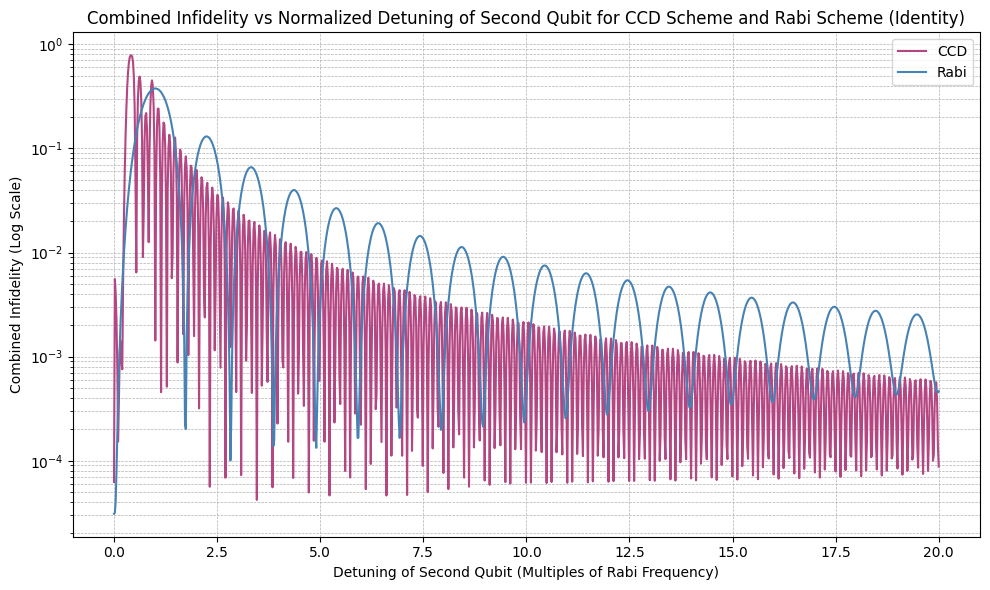

In [60]:
# find combdined infidelity
infidelities_combined_ccd = 1-np.array(final_fids_combined_ccd)
infidelities_combined_rabi = 1-np.array(final_fids_combined_rabi)

# Normalize detunings by Rabi frequency
detunings_normalized = detunings / rabi_freq

# Plot combined infidelity vs normalized detuning on a logarithmic scale
plt.figure(figsize=(10, 6))
plt.semilogy(detunings_normalized, infidelities_combined_ccd, label="CCD", color=plum)
plt.semilogy(detunings_normalized, infidelities_combined_rabi, label="Rabi", color=steel_blue)
plt.xlabel("Detuning of Second Qubit (Multiples of Rabi Frequency)")
plt.ylabel("Combined Infidelity (Log Scale)")
plt.title("Combined Infidelity vs Normalized Detuning of Second Qubit for CCD Scheme and Rabi Scheme (Identity)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()
